# Step 1 : Libraries

In [14]:
# Task 2: Customer Segmentation Analysis
# Intern: Suraj Kumar | OIB/J2/IP2626

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


# Step 2 : Data Loading

In [17]:
import os
print(os.getcwd())
print(os.listdir())

c:\Users\Suraj\OneDrive\문서\Desktop\OIBSIP\Task2_Customer_Segmentation
['iFood.csv', 'SurajKumar_Task2.ipynb']


In [19]:
# Step 2: Data Loading
df = pd.read_csv('iFood.csv')

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nFirst 5 rows:")
print(df.head())

Shape: (2205, 29)

Columns: ['Index', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntRegularProds', 'MntGoldProds', 'MntTotal', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmpOverall', 'Complain', 'Age', 'Customer_Days', 'marital_status', 'education']

First 5 rows:
   Index  Income  Kidhome  Teenhome  Recency  MntWines  MntFruits  \
0   1001   58138        0         0       58       635         88   
1   1002   46344        1         1       38        11          1   
2   1003   71613        0         0       26       426         49   
3   1004   26646        1         0       26        11          4   
4   1005   58293        1         0       94       173         43   

   MntMeatProducts  MntFishProducts  MntSweetProducts  ...  AcceptedCmp2  \
0       

# Step 3 : Data Cleaning

In [22]:
# Step 3 : Data Cleaning

print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

print("\nBasic Statistics:")
print(df[['Age','Income','MntTotal']].describe().round(2))

Missing Values:
Index                  0
Income                 0
Kidhome                0
Teenhome               0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntRegularProds        0
MntGoldProds           0
MntTotal               0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp1           0
AcceptedCmp2           0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmpOverall     0
Complain               0
Age                    0
Customer_Days          0
marital_status         0
education              0
dtype: int64

Duplicate Rows: 0

Data Types:
Index                   int64
Income                  int64
Kidhome                 int64
Teenhome                int64
Recency                 int64
MntWines                int64
MntFruits               int64
MntM

# Step 4 : Descriptive Statistics

In [23]:
# Step 4 : Descriptive Statistics

print("Basic Statistics:")
print(df[['Age', 'Income', 'MntTotal', 'Recency']].describe().round(2))

print("\nMarital Status Distribution:")
print(df['marital_status'].value_counts())

print("\nEducation Distribution:")
print(df['education'].value_counts())

print("\nAvg Income:", round(df['Income'].mean(),2))
print("\nAvg Age:", round(df['Age'].mean(),2))
print("Avg Total Spending:", round(df['MntTotal'].mean(),2))


Basic Statistics:
           Age     Income  MntTotal  Recency
count  2205.00    2205.00   2205.00  2205.00
mean     51.10   51622.09    562.76    49.01
std      11.71   20713.06    575.94    28.93
min      24.00    1730.00      4.00     0.00
25%      43.00   35196.00     56.00    24.00
50%      50.00   51287.00    343.00    49.00
75%      61.00   68281.00    964.00    74.00
max      80.00  113734.00   2491.00    99.00

Marital Status Distribution:
marital_status
Married     854
Together    568
Single      477
Divorced    230
Widow        76
Name: count, dtype: int64

Education Distribution:
education
Graduation    1113
PHD            476
Master         364
2n Cycle       198
Basic           54
Name: count, dtype: int64

Avg Income: 51622.09

Avg Age: 51.1
Avg Total Spending: 562.76


# Step 5 : Visualization

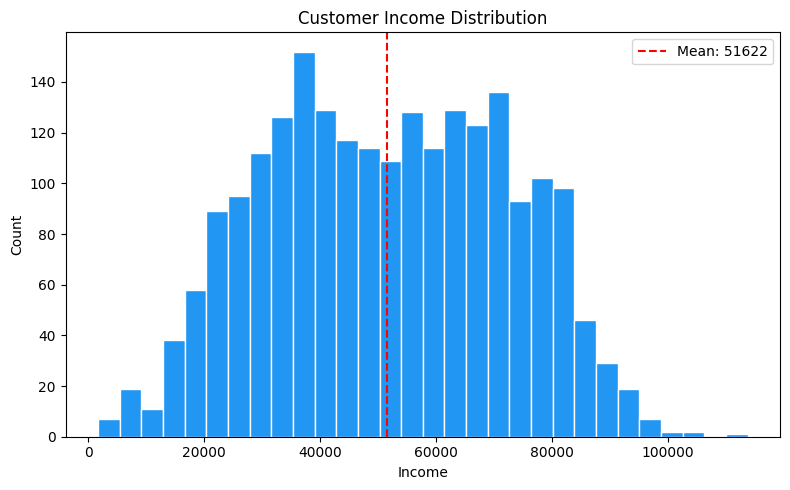

In [24]:
# Step 5 : Visualization
# Graph 1 - Income Distribution

plt.figure(figsize=(8,5))
plt.hist(df['Income'], bins=30, color='#2196F3', edgecolor='white')
plt.title('Customer Income Distribution')
plt.xlabel('Income')
plt.ylabel('Count')
plt.axvline(df['Income'].mean(), color='red',
            linestyle='--', label=f'Mean: {df["Income"].mean():.0f}')
plt.legend()
plt.tight_layout()
plt.show()


### Grarh 2 - Spending vs Income

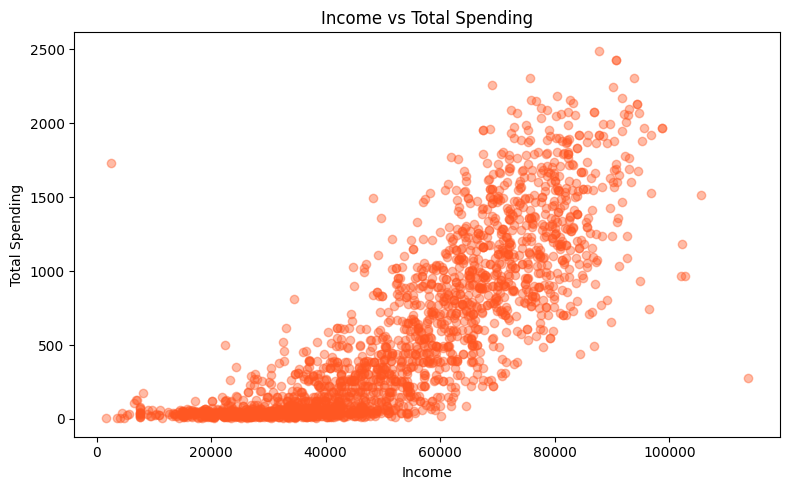

In [26]:
# Graph 2 - Spending vs Income 

plt.figure(figsize=(8,5))
plt.scatter(df['Income'], df['MntTotal'],
            alpha=0.4, color='#FF5722')
plt.title('Income vs Total Spending')
plt.xlabel('Income')
plt.ylabel('Total Spending')
plt.tight_layout()
plt.show()

### Graph 3 - Marital Status vs Spending

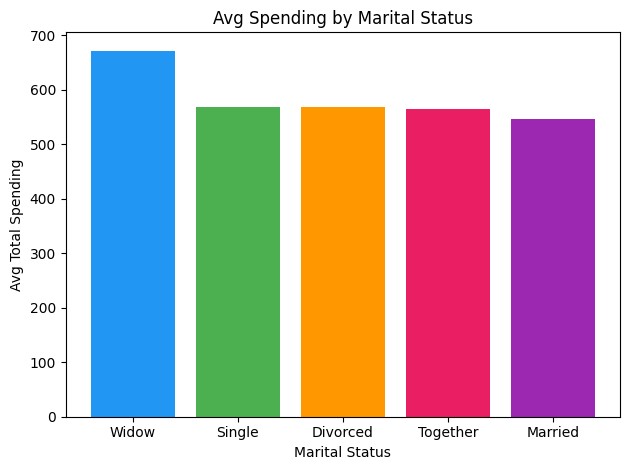

In [27]:
# Graph 3 - Marital Status vs Spending

plt.Figure(figsize=(8,5))
marital_spending = df.groupby('marital_status')['MntTotal'].mean().sort_values(ascending=False)
plt.bar(marital_spending.index, marital_spending.values,
        color=['#2196F3', '#4CAF50', '#FF9800', '#E91E63','#9C27B0'])
plt.title('Avg Spending by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Avg Total Spending')
plt.tight_layout()
plt.show()

# Step 6 : K-Means Clusteing

In [31]:
# Step 6: K-Means Clustering
features = df[['Income', 'MntTotal', 'Age', 'Recency']]

# Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

# Apply K-Means with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_data)

print("Cluster Distribution:")
print(df['Cluster'].value_counts())

print("\nCluster wise Avg Stats:")
print(df.groupby('Cluster')[['Income','MntTotal','Age','Recency']].mean().round(2))

Cluster Distribution:
Cluster
0    593
3    573
1    568
2    471
Name: count, dtype: int64

Cluster wise Avg Stats:
           Income  MntTotal    Age  Recency
Cluster                                    
0        75151.61   1320.17  49.47    55.61
1        32431.86    116.63  42.77    30.65
2        57986.68    579.10  62.35    27.25
3        41062.47    207.74  51.78    78.27


### Graph 4 - Cluster Visualization

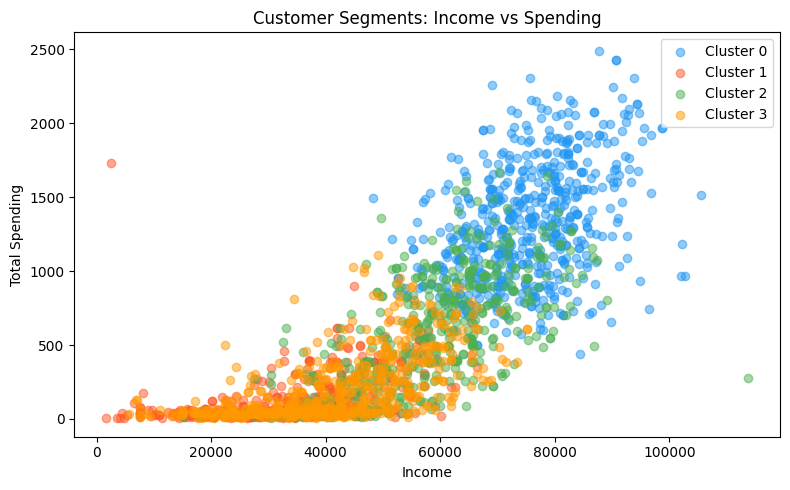

In [32]:
# Graph 4 - Cluster Scatter Plot
plt.figure(figsize=(8,5))
colors = ['#2196F3', '#FF5722', '#4CAF50', '#FF9800']
for i in range(4):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(cluster_data['Income'], 
                cluster_data['MntTotal'],
                c=colors[i], label=f'Cluster {i}', alpha=0.5)
plt.title('Customer Segments: Income vs Spending')
plt.xlabel('Income')
plt.ylabel('Total Spending')
plt.legend()
plt.tight_layout()
plt.show()

# Step 7 - Recommendationns

In [33]:
# Step 7: Insights & Recommendations
print("=" * 55)
print("CUSTOMER SEGMENTATION - INSIGHTS & RECOMMENDATIONS")
print("=" * 55)
print("""
CLUSTER 0 - HIGH VALUE CUSTOMERS (593 customers)
  - Highest Income: 75,151 | Highest Spending: 1,320
  - Strategy: VIP programs, premium products, loyalty rewards

CLUSTER 1 - LOW VALUE CUSTOMERS (568 customers)
  - Lowest Income: 32,431 | Lowest Spending: 116
  - Strategy: Discounts, deals, budget friendly offers

CLUSTER 2 - MID SENIOR CUSTOMERS (471 customers)
  - Mid Income: 57,986 | Mid Spending: 579
  - Oldest Age: 62 years
  - Strategy: Senior targeted products, health products

CLUSTER 3 - AT RISK CUSTOMERS (573 customers)
  - Low Income: 41,062 | Low Spending: 207
  - Highest Recency: 78 days since last purchase
  - Strategy: Re-engagement campaigns, special offers
""")
print("=" * 55)
print("Task 2 Complete! - Suraj Kumar | OIB/J2/IP2626")
print("=" * 55)

CUSTOMER SEGMENTATION - INSIGHTS & RECOMMENDATIONS

CLUSTER 0 - HIGH VALUE CUSTOMERS (593 customers)
  - Highest Income: 75,151 | Highest Spending: 1,320
  - Strategy: VIP programs, premium products, loyalty rewards

CLUSTER 1 - LOW VALUE CUSTOMERS (568 customers)
  - Lowest Income: 32,431 | Lowest Spending: 116
  - Strategy: Discounts, deals, budget friendly offers

CLUSTER 2 - MID SENIOR CUSTOMERS (471 customers)
  - Mid Income: 57,986 | Mid Spending: 579
  - Oldest Age: 62 years
  - Strategy: Senior targeted products, health products

CLUSTER 3 - AT RISK CUSTOMERS (573 customers)
  - Low Income: 41,062 | Low Spending: 207
  - Highest Recency: 78 days since last purchase
  - Strategy: Re-engagement campaigns, special offers

Task 2 Complete! - Suraj Kumar | OIB/J2/IP2626
